# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The data was collected from a Portuguese retail bank over a span of five years from May 2008 to June 2013 for a total of 52944 phone contacts. Every phone call to a potential customer was considered a campaign attempt a**nd maximum number of attempted "compaigns" was 43 in this dataset.**



### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import math
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import time
import os

from itertools import combinations

In [3]:
# Mount a drive to store the data file (vehicles.csv)
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

# Set the folder name where vehicles.csv is stored
file_path = f'/content/drive/My Drive/Data/bank-additional-full.csv'

# Load the CSV file into a DataFrame
if os.path.exists(file_path):
    df = pd.read_csv(file_path, sep = ';')
    print("File loaded successfully!")
    display(df.head())
else:
    print(f"File not found at: {file_path}\nPlease check the folder name variable.")

Mounted at /content/drive
File loaded successfully!


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [6]:
df.info()

# Cleaning up the data
original_rows = len(df)
# Remove any rows that contain the exact string 'unknown' in any of their columns
df_clean = df[(df != 'unknown').all(axis=1)]
remaining_rows = len(df_clean)
removed_rows = original_rows - remaining_rows

# Select numerical columns from the cleaned dataset
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64'])

# Calculate min and max
min_max_df = numerical_cols.agg(['min', 'max']).T
min_max_df.columns = ['Minimum', 'Maximum']

print("--- Minimum and Maximum Values for Numerical Features ---")
display(min_max_df)

print("--- Data Cleaning Report ---")
print("Action Taken: Filtered the DataFrame to remove rows containing 'unknown'.")
print(f"Original number of rows: {original_rows}")
print(f"Number of rows removed:  {removed_rows}")
print(f"Number of rows remaining: {remaining_rows}")
print(f"Percentage of data retained: {(remaining_rows/original_rows)*100:.2f}%")

# Calculate and display the number of unique values for each column
unique_counts = df_clean.nunique().to_frame(name='Number of Unique Values')
print("--- Number of Unique Values per Column ---")
display(unique_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,Minimum,Maximum
age,17.000,95.000
duration,0.000,4918.000
campaign,1.000,43.000
pdays,0.000,999.000
previous,0.000,7.000
emp.var.rate,-3.400,1.400
cons.price.idx,92.201,94.767
cons.conf.idx,-50.800,-26.900
euribor3m,0.634,5.045
nr.employed,4963.600,5228.100


--- Data Cleaning Report ---
Action Taken: Filtered the DataFrame to remove rows containing 'unknown'.
Original number of rows: 41188
Number of rows removed:  10700
Number of rows remaining: 30488
Percentage of data retained: 74.02%
--- Number of Unique Values per Column ---


,Number of Unique Values
age,76
job,11
marital,3
education,7
default,2
housing,2
loan,2
contact,2
month,10
day_of_week,5


**Understanding Data:**

Based on the `df.info()` output (which shows non-null counts) and the provided data description, here's an assessment of potential missing values and data type considerations:

**Missing Values:**

While `df.info()` will likely show that all columns have a full count of non-null entries (meaning no standard `NaN` values), the data description specifies certain values that should be considered as missing or requiring special handling:

*   **Categorical Features with 'unknown'**: **bold text** The `job`, `marital`, `education`, `default`, `housing`, and `loan` columns explicitly list 'unknown' as a possible category. These 'unknown' values should be treated as missing data for modeling purposes and may require imputation or removal.
*   **`pdays` (numeric)**: The value `999` in the `pdays` column indicates that the client was `not previously contacted`. This is a specific sentinel value representing a type of missing information (no previous contact) and should be handled appropriately (e.g., converting to NaN, or creating a separate binary feature).

**Data Type Coercion:**

*   All columns appear to be loaded with appropriate data types by pandas (`int64` for numeric, `object` for categorical strings). No explicit coercion is immediately necessary for basic loading.
*   However, for modeling, the `object` (string) type categorical columns (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`, `y`) will need to be **encoded** (e.g., using One-Hot Encoding or Label Encoding) into numerical formats.
*   The `y` (target) column is binary ('yes'/'no') and will need to be converted to numerical (e.g., 0/1).

**Other Considerations:**

*   **`duration` (numeric)**: The description explicitly states that this attribute `should be discarded if the intention is to have a realistic predictive model` because it's only known after the call and highly influences the target. This column should likely be dropped for most predictive tasks, but kept for benchmarking.

**Summary of the data cleaning process:**

Action Taken: The dataset was filtered to completely remove any rows that contained the exact string 'unknown' in any of their columns.

- **Original Dataset Size:** 41,188 rows

- **Rows Removed:** 10,700 rows

- **Cleaned Dataset Size:** 30,488 rows

- **Data Retention:** 74.02% of the original data was retained for further analysis and modeling.

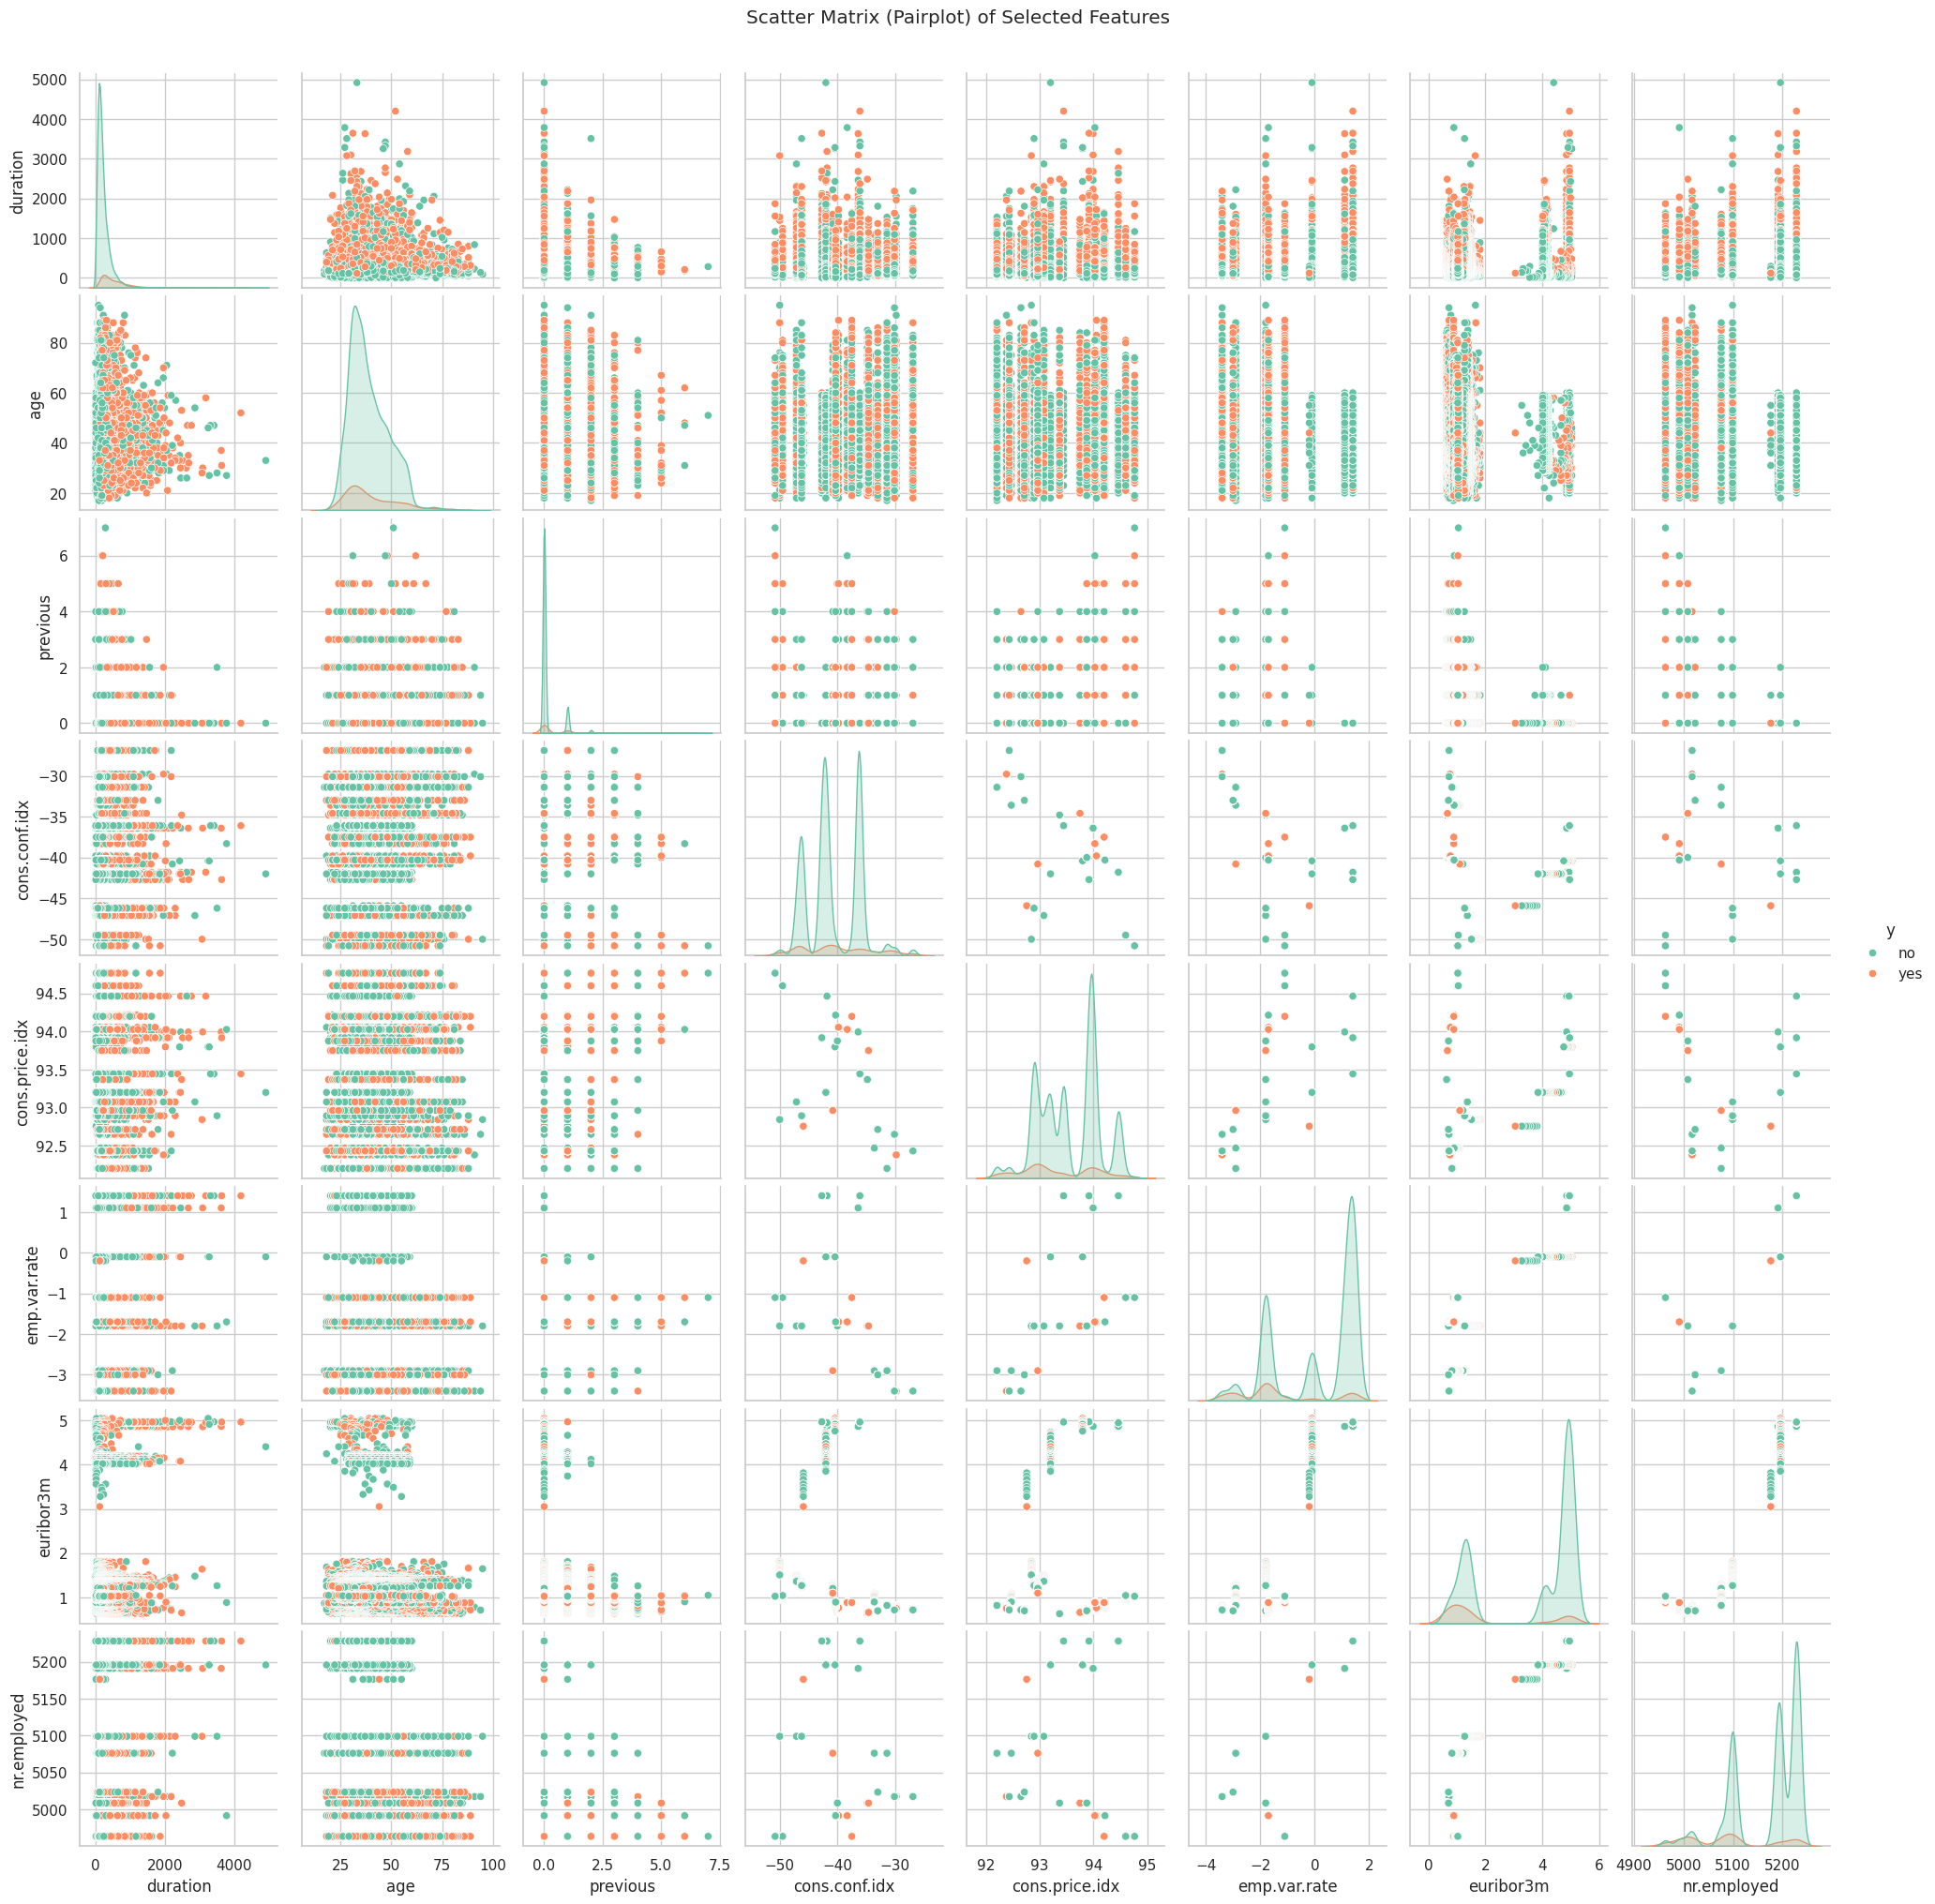

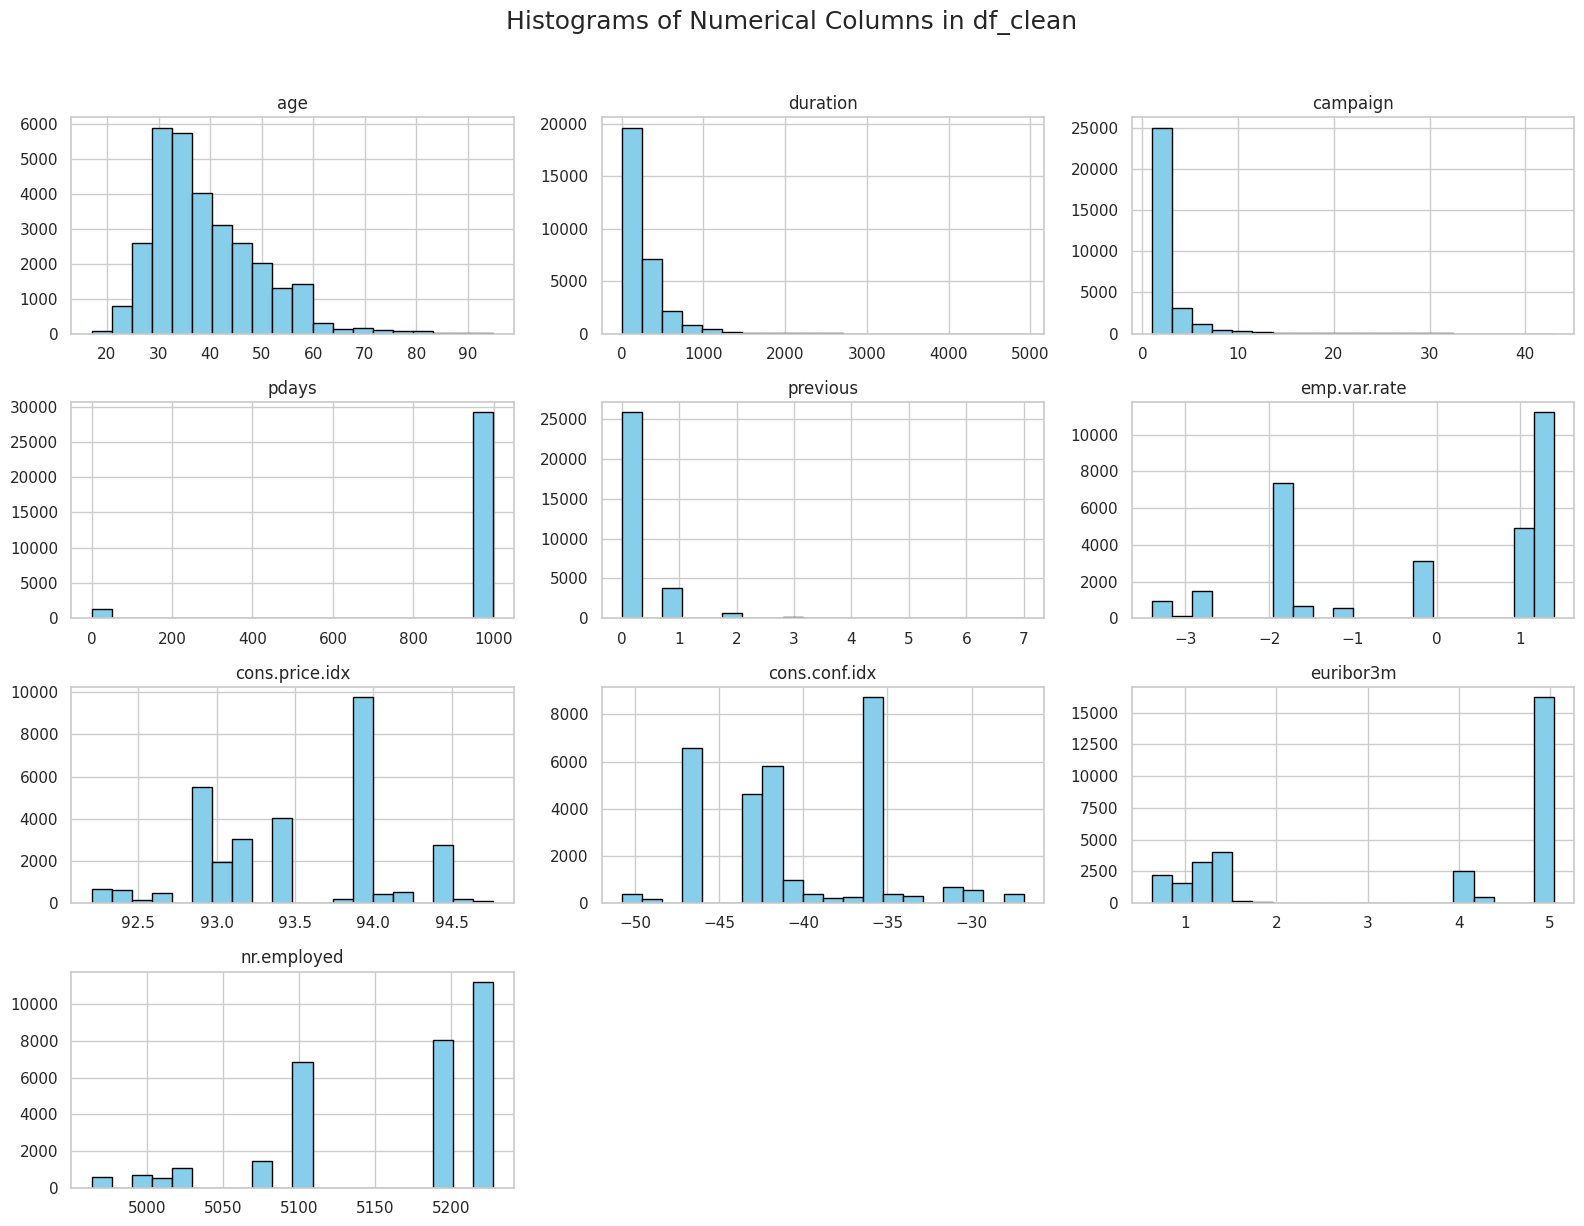

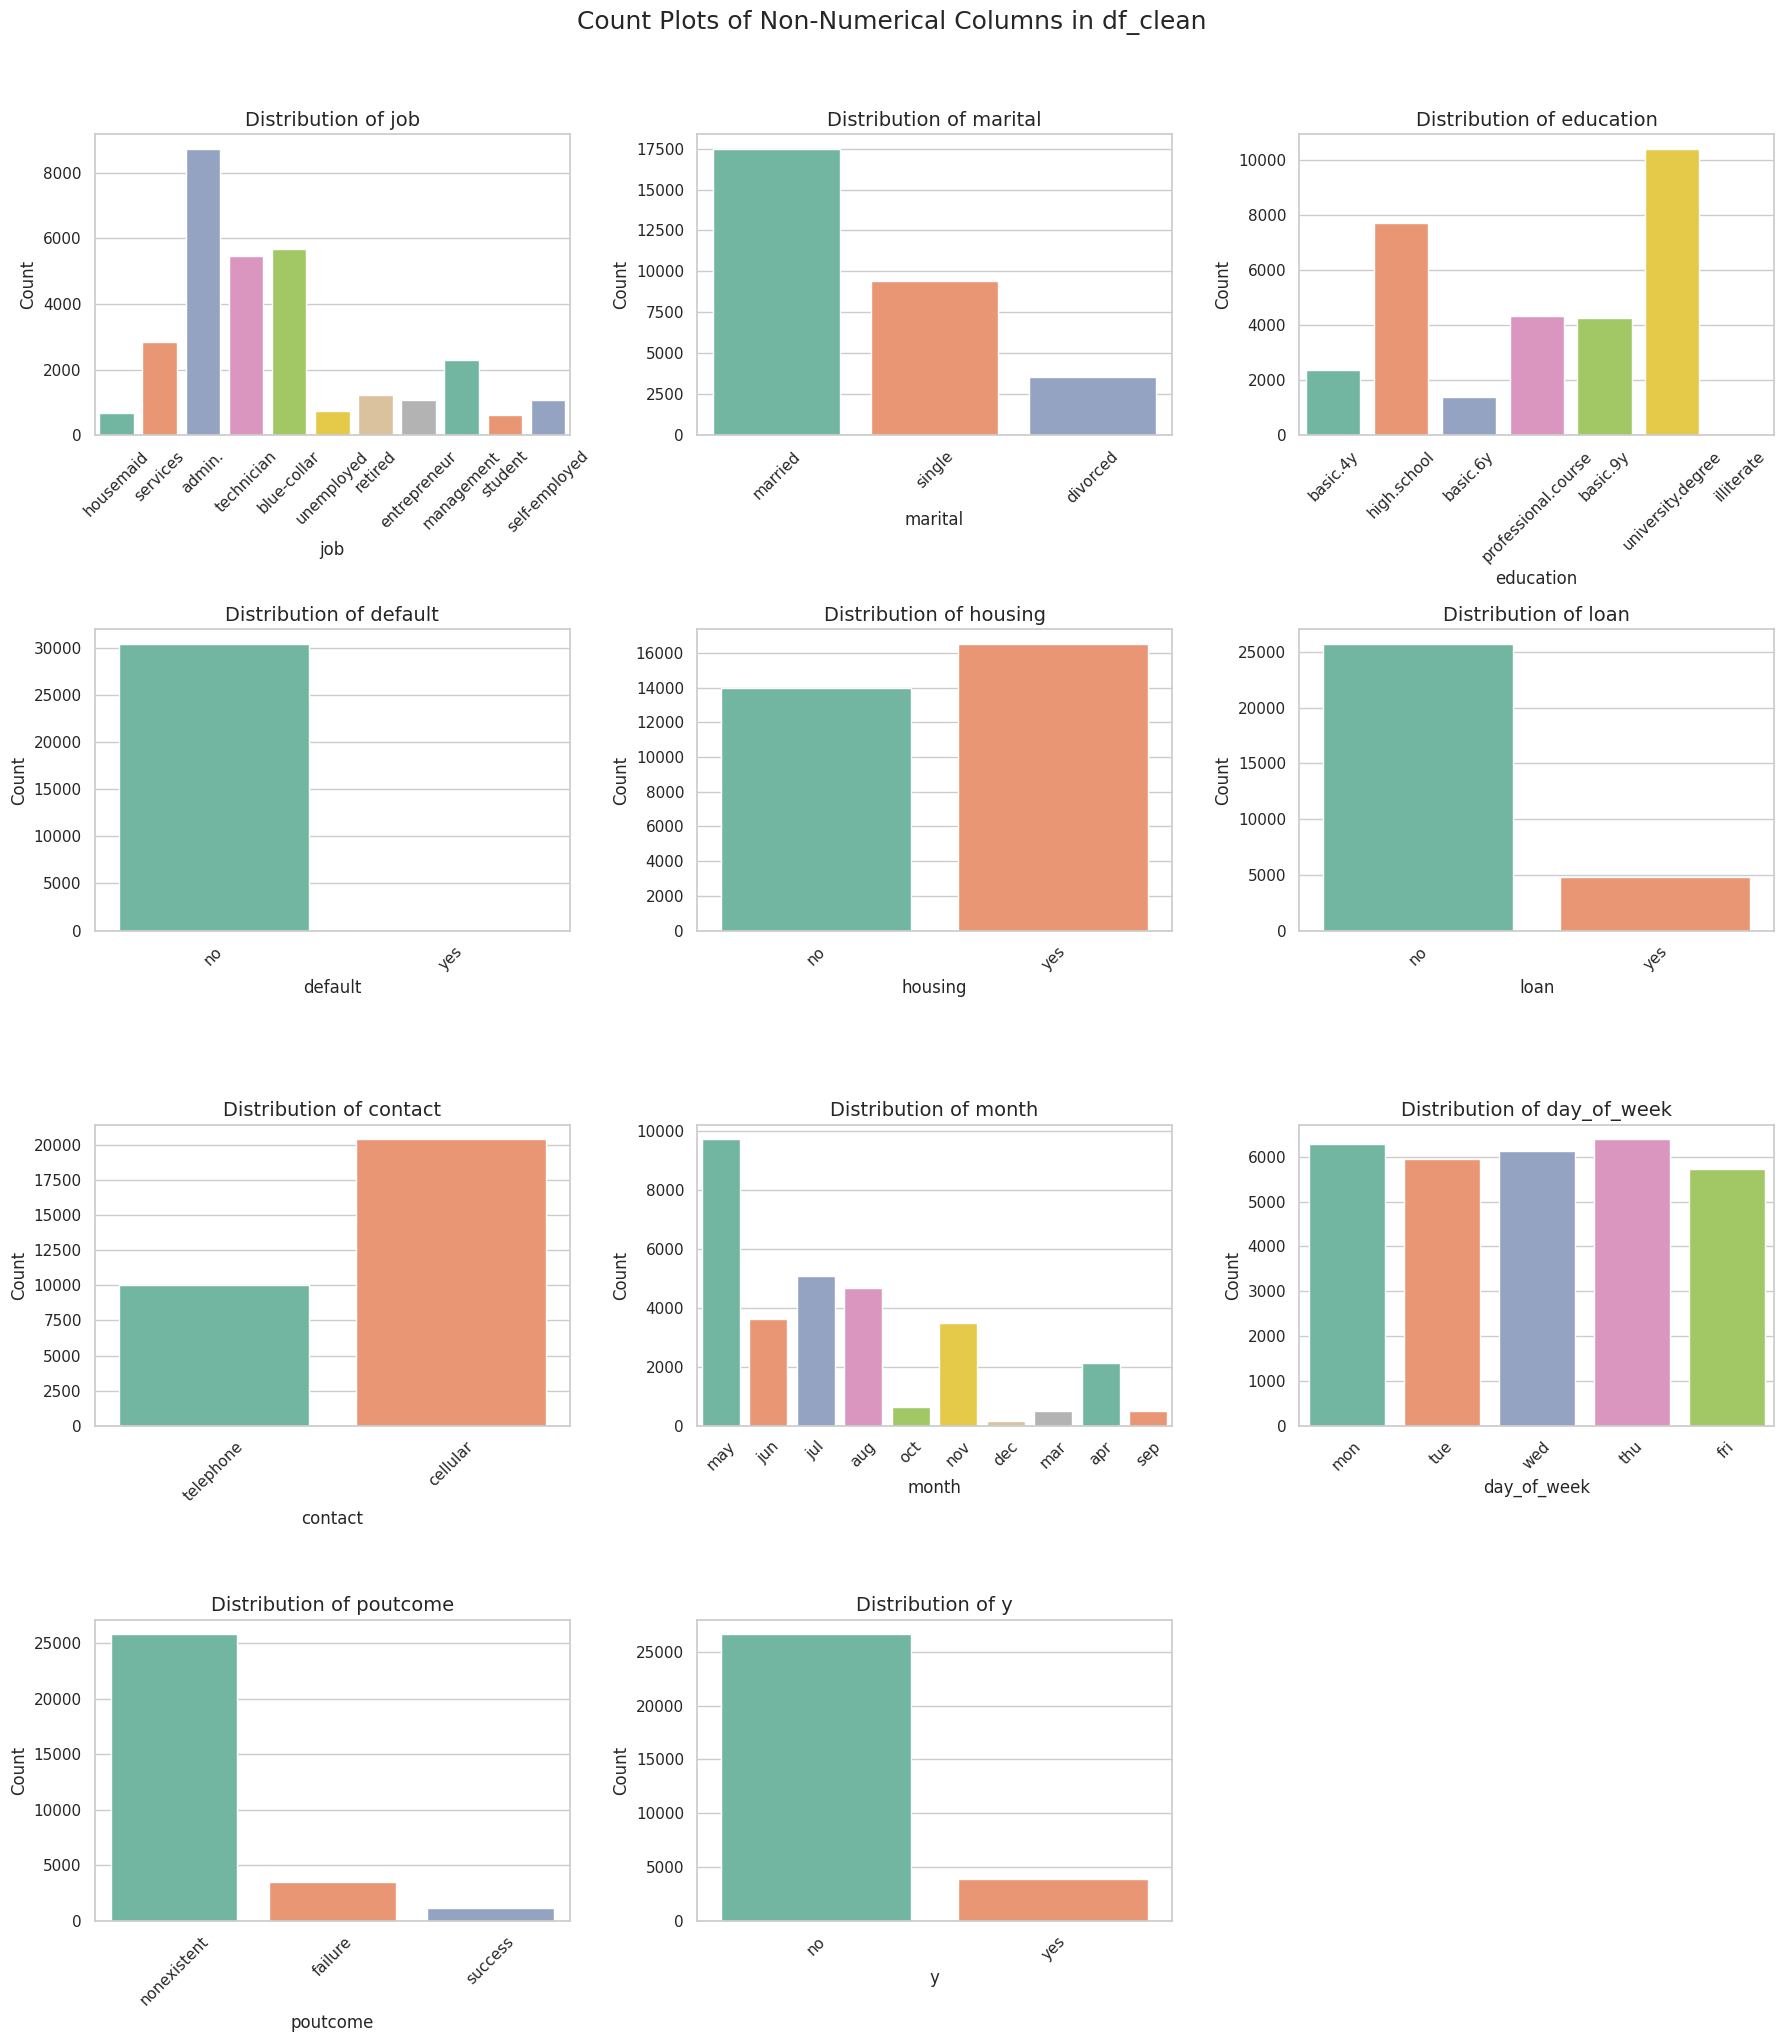

In [5]:
#Data Visualization

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Select numeric columns
cols_to_plot = ['duration', 'age', 'previous', 'cons.conf.idx', 'cons.price.idx', 'emp.var.rate', 'euribor3m', 'nr.employed', 'y']

# Generate pairplots
sns.pairplot(df_clean[cols_to_plot], hue='y', palette='Set2')
plt.suptitle('Scatter Matrix (Pairplot) of Selected Features', y=1.02)
plt.show()

# Plot histograms for all numerical columns in df_clean
df_clean.hist(bins=20, figsize=(16, 12), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Columns in df_clean', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# Plot count plots (bar charts) for all non-numerical (categorical) columns in df_clean
cat_cols = df_clean.select_dtypes(include=['object']).columns
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_clean, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Count Plots of Non-Numerical Columns in df_clean', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

**Data Insights**

- Pairplots clearly show that data is imbalanced with “no” outcomes far outweighing “yes”. Visually inspecting pairplots did not reveal that any feature can naturally separate “yes” and “no”.  Furthermore, except for age and euribor rate, the other numeric data are discrete with limited number of values. As such data presentation in decision space for those features would be highly clustered.

- Histograms show that data is well-behaved with no apparent outliers.

- Interestingly, count plots reveal interesting categorical features.  For example,  most calls  were carried over cell phone, during month of May, to married individuals with an administrative job who also had a university  degree.



### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective**

The primary business objective is to develop a predictive model that can accurately classify whether
a bank client will subscribe to a term deposit (the target variable, `y`) based on their demographic
information, past interactions, and current economic indicators.

By successfully predicting this outcome, the bank can:
1. Optimize Marketing Campaigns:  Targeting customers who are most likely to subscribe and reduce the time and cost spent on calling unlikely prospects.

2. Resource Allocation: Improve the efficiency of the telemarketing team.
3. Increase Conversion Rates:Ultimately drive more revenue by focusing efforts on high-probability leads.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [7]:
# Encoding data

# Create a copy to avoid modifying the original dataframe
df_encoded = df_clean.copy()

# Dictionary to hold the reporting information
encoding_report = {}

# 1. Target Variable Encoding (Binary)
df_encoded['y'] = df_encoded['y'].map({'no': 0, 'yes': 1})
encoding_report['y'] = 'Binary Encoding (no: 0, yes: 1)'

# 2. Drop 'duration' as advised in the data description (Problem 3)
df_encoded = df_encoded.drop(columns=['duration'])
encoding_report['duration'] = 'Dropped (to prevent data leakage)'

# 3. Categorical Variables (Features) Encoding
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    encoding_report[col] = 'One-Hot Encoding (drop_first=True)'

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

# 4. Numerical Variables (already numeric)
original_numeric = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in original_numeric:
    if col != 'duration':
        encoding_report[col] = 'None (Already Numeric)'

# Print the Encoding Report
print("--- Column Encoding Report ---")
for col, encoding in sorted(encoding_report.items()):
    print(f"{col:15}: {encoding}")

print(f"\nOriginal Shape: {df_clean.shape}")
print(f"Encoded Shape:  {df_encoded.shape}")
display(df_encoded.head())

--- Column Encoding Report ---
age            : None (Already Numeric)
campaign       : None (Already Numeric)
cons.conf.idx  : None (Already Numeric)
cons.price.idx : None (Already Numeric)
contact        : One-Hot Encoding (drop_first=True)
day_of_week    : One-Hot Encoding (drop_first=True)
default        : One-Hot Encoding (drop_first=True)
duration       : Dropped (to prevent data leakage)
education      : One-Hot Encoding (drop_first=True)
emp.var.rate   : None (Already Numeric)
euribor3m      : None (Already Numeric)
housing        : One-Hot Encoding (drop_first=True)
job            : One-Hot Encoding (drop_first=True)
loan           : One-Hot Encoding (drop_first=True)
marital        : One-Hot Encoding (drop_first=True)
month          : One-Hot Encoding (drop_first=True)
nr.employed    : None (Already Numeric)
pdays          : None (Already Numeric)
poutcome       : One-Hot Encoding (drop_first=True)
previous       : None (Already Numeric)
y              : Binary Encoding (no: 

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
6,59,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [8]:
# Split the data

# Define features (X) and target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (24390, 46)
X_test shape: (6098, 46)
y_train shape: (24390,)
y_test shape: (6098,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [9]:
# Calculate the distribution of the target variable in the training set
class_distribution = y_train.value_counts(normalize=True)
print("Class Distribution (Training Set):")
print(class_distribution)

# The baseline accuracy is the proportion of the majority class
baseline_accuracy = class_distribution.max()
print(f"\nBaseline Accuracy (always predicting majority class): {baseline_accuracy * 100:.2f}%")

Class Distribution (Training Set):
y
0    0.874334
1    0.125666
Name: proportion, dtype: float64

Baseline Accuracy (always predicting majority class): 87.43%


**Baseline Accuracy**

The baseline accuracy for this dataset is **87.43%**.

If we ignor all customer features and simply predicted "No" (the majority class) for every single call, it would be correct 87.43% of the time.

 This serves as the absolute minimum threshold the machine learning classifiers need to beat.

**The Trap of Imbalanced Data:** Because the baseline is so imbalanced, relying solely on "Accuracy" can be highly misleading. A model could achieve an 88% accuracy by almost always predicting "No", but it would completely fail our business objective of identifying the actual "Yes" customers. This highlights why we must evaluate our models using metrics that are robust to class imbalance, such as  **ROC AUC**.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [10]:
from sklearn.preprocessing import StandardScaler
import time

# Scale the data
scaler = StandardScaler()
X_train_scaled_simple = scaler.fit_transform(X_train)

# Instantiate the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model on the scaled training data and measure the training time
start_time = time.time()
log_reg.fit(X_train_scaled_simple, y_train)
train_time = time.time() - start_time

print(f"Logistic Regression model trained successfully on scaled data in {train_time:.4f} seconds.")

Logistic Regression model trained successfully on scaled data in 0.5898 seconds.


### Problem 9: Score the Model

What is the accuracy of your model?

--- Logistic Regression Evaluation ---
Accuracy:  0.8857
Precision: 0.6777
Recall:    0.2330
ROC AUC:   0.7972


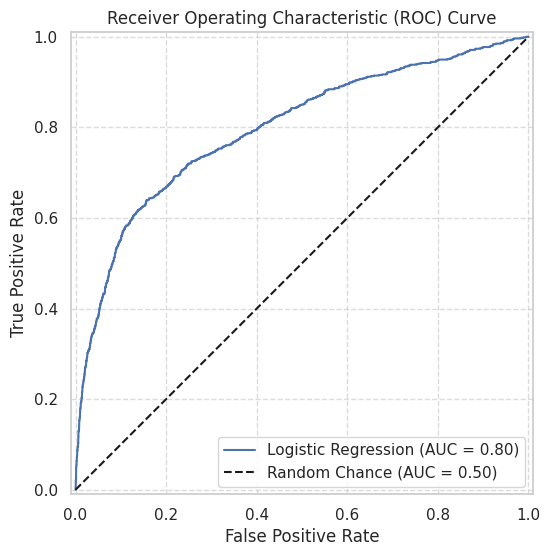

In [11]:
# Scale the test set using the already fitted scaler
X_test_scaled_simple = scaler.transform(X_test)

# Make predictions on the scaled test set
y_pred = log_reg.predict(X_test_scaled_simple)
y_pred_proba = log_reg.predict_proba(X_test_scaled_simple)[:, 1]

# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print the results
print("--- Logistic Regression Evaluation ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

# Plot the ROC curve for the Logistic Regression model
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    log_reg,
    X_test_scaled_simple,
    y_test,
    ax=plt.gca(),
    name='Logistic Regression'
)

# Add a diagonal line for random chance
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Accuracy (0.8857)**: It is slightly better than our baseline accuracy (0.8743), meaning it's doing a little better than just guessing 'no' every time.

**Precision (0.6777)**: When the model predicts someone will subscribe to a term deposit, it is correct about 68% of the time.

**Recall (0.2330)**: This is quite low. The model only successfully identifies 23% of the people who actually ended up subscribing.

**ROC AUC (0.7972) & The ROC Curve**: Given the data is highly imbalanced, this is the most appropriate evaluation metric. The ROC curve plots the True Positive Rate against the False Positive Rate at various decision threshold settings.

The plotted curve bows significantly towards the top-left corner, pulling far away from the dotted diagonal line (which represents random guessing).

An AUC (Area Under the Curve) of ~0.80 means there is an 80% chance that the model will assign a higher predicted probability to a randomly chosen positive instance (a true 'Yes') than to a randomly chosen negative instance (a true 'No'). This proves the model has successfully learned the strong underlying global linear trends (like the economic indicators) to effectively separate the two classes.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [12]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models with default settings
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

results = []

for name, model in models.items():
    # Measure training time
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Calculate Train Accuracy
    train_acc = model.score(X_train_scaled, y_train)

    # Calculate Test Accuracy
    test_acc = model.score(X_test_scaled, y_test)

    # Calculate ROC AUC
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        # SVM default uses decision_function instead of probabilities
        y_pred_proba = model.decision_function(X_test_scaled)

    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Store the results
    results.append({
        'Model': name,
        'Train Time': train_time,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'ROC AUC': roc_auc
    })

# Create and display the DataFrame
comparison_df = pd.DataFrame(results)
display(comparison_df)


,Model,Train Time,Train Accuracy,Test Accuracy,ROC AUC
0,Logistic Regression,0.607253,0.889709,0.885700,0.797201
1,KNN,0.015228,0.905986,0.871597,0.725269
2,Decision Tree,0.206516,0.994383,0.823221,0.625884
3,SVM,75.342729,0.900492,0.881109,0.711065


- **Logistic Regression** is currently performing the best
overall, achieving the highest ROC AUC (0.80) and test accuracy (0.89), while being extremely fast to train.


- **Decision Tree** is severely overfitting the data. It has nearly 100% training accuracy but the lowest test accuracy and ROC AUC (~0.63).

- **SVM** took significantly longer to train than the others (around 52 seconds) but didn't beat Logistic Regression in performance.

- **KNN** is very fast but its ROC AUC is lower than Logistic Regression.


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [13]:
# Hyperparameter Tuning for Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Using ROC AUC as the scoring metric due to class imbalance
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Starting Grid Search for Decision Tree...")
start_time = time.time()
dt_grid.fit(X_train_scaled, y_train)
dt_tune_time = time.time() - start_time

print(f"Tuning completed in {dt_tune_time:.2f} seconds.")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best Cross-Validation ROC AUC: {dt_grid.best_score_:.4f}")

# Evaluate the best model on the test set
best_dt = dt_grid.best_estimator_
dt_test_proba = best_dt.predict_proba(X_test_scaled)[:, 1]
dt_test_roc_auc = roc_auc_score(y_test, dt_test_proba)
print(f"Test Set ROC AUC for Best Decision Tree: {dt_test_roc_auc:.4f}\n")

# Calculate Train and Test Accuracy for the tuned model
dt_train_acc = best_dt.score(X_train_scaled, y_train)
dt_test_acc = best_dt.score(X_test_scaled, y_test)

# Report results in a DataFrame like the previous cell
tuned_dt_results = pd.DataFrame([{
    'Model': 'Tuned Decision Tree',
    'Train Time': dt_tune_time,
    'Train Accuracy': dt_train_acc,
    'Test Accuracy': dt_test_acc,
    'ROC AUC': dt_test_roc_auc
}])

# Combine with the previous comparison dataframe
updated_comparison_df = pd.concat([comparison_df, tuned_dt_results], ignore_index=True)

# Reorder to place Tuned Decision Tree right below Decision Tree
dt_idx = updated_comparison_df[updated_comparison_df['Model'] == 'Decision Tree'].index[0]
tuned_dt_idx = updated_comparison_df[updated_comparison_df['Model'] == 'Tuned Decision Tree'].index[0]

new_order = list(range(len(updated_comparison_df)))
new_order.remove(tuned_dt_idx)
new_order.insert(dt_idx + 1, tuned_dt_idx)

updated_comparison_df = updated_comparison_df.iloc[new_order].reset_index(drop=True)

# Display the reordered dataframe
display(updated_comparison_df)


Starting Grid Search for Decision Tree...
Tuning completed in 27.42 seconds.
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Cross-Validation ROC AUC: 0.7853
Test Set ROC AUC for Best Decision Tree: 0.7708



,Model,Train Time,Train Accuracy,Test Accuracy,ROC AUC
0,Logistic Regression,0.607253,0.889709,0.885700,0.797201
1,KNN,0.015228,0.905986,0.871597,0.725269
2,Decision Tree,0.206516,0.994383,0.823221,0.625884
3,Tuned Decision Tree,27.415861,0.892620,0.886356,0.770768
4,SVM,75.342729,0.900492,0.881109,0.711065


**Hyperparameter Tuning for Decision Tree**

As we can see, tuning the hyperparameters (max_depth=5, min_samples_leaf=10, min_samples_split=2) completely eliminated the severe overfitting from the baseline model (which had ~99.4% train accuracy but only ~62.6% test ROC AUC). The tuned model generalizes much better to the unseen test data.

In [14]:
# Hyperparameter Tuning for KNN

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # 1: Manhattan, 2: Euclidean
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Starting Grid Search for KNN...")
start_time = time.time()
knn_grid.fit(X_train_scaled, y_train)
knn_tune_time = time.time() - start_time

print(f"Tuning completed in {knn_tune_time:.2f} seconds.")
print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Best Cross-Validation ROC AUC: {knn_grid.best_score_:.4f}")

# Evaluate the best model on the test set
best_knn = knn_grid.best_estimator_
knn_test_proba = best_knn.predict_proba(X_test_scaled)[:, 1]
knn_test_roc_auc = roc_auc_score(y_test, knn_test_proba)
print(f"Test Set ROC AUC for Best KNN: {knn_test_roc_auc:.4f}\n")

# Calculate Train and Test Accuracy for the tuned model
knn_train_acc = best_knn.score(X_train_scaled, y_train)
knn_test_acc = best_knn.score(X_test_scaled, y_test)

# Report results in a DataFrame like the previous cell
tuned_knn_results = pd.DataFrame([{
    'Model': 'Tuned KNN',
    'Train Time': knn_tune_time,
    'Train Accuracy': knn_train_acc,
    'Test Accuracy': knn_test_acc,
    'ROC AUC': knn_test_roc_auc
}])

# Combine with the previous comparison dataframe and display
updated_comparison_df = pd.concat([updated_comparison_df, tuned_knn_results], ignore_index=True)

# Drop duplicates keeping the last calculated metrics FIRST
updated_comparison_df = updated_comparison_df.drop_duplicates(subset=['Model'], keep='last').reset_index(drop=True)

# Reorder to place Tuned KNN right below KNN
knn_idx = updated_comparison_df[updated_comparison_df['Model'] == 'KNN'].index[0]
tuned_knn_idx = updated_comparison_df[updated_comparison_df['Model'] == 'Tuned KNN'].index[0]

new_order = list(range(len(updated_comparison_df)))
new_order.remove(tuned_knn_idx)
new_order.insert(knn_idx + 1, tuned_knn_idx)

updated_comparison_df = updated_comparison_df.iloc[new_order].reset_index(drop=True)

display(updated_comparison_df)


Starting Grid Search for KNN...
Tuning completed in 265.27 seconds.
Best Parameters: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
Best Cross-Validation ROC AUC: 0.7616
Test Set ROC AUC for Best KNN: 0.7523



,Model,Train Time,Train Accuracy,Test Accuracy,ROC AUC
0,Logistic Regression,0.607253,0.889709,0.885700,0.797201
1,KNN,0.015228,0.905986,0.871597,0.725269
2,Tuned KNN,265.274413,0.896023,0.878485,0.752342
3,Decision Tree,0.206516,0.994383,0.823221,0.625884
4,Tuned Decision Tree,27.415861,0.892620,0.886356,0.770768
5,SVM,75.342729,0.900492,0.881109,0.711065



**Hyperparameter Tuning for KNN**

Tuning for the KNN model searches for the optimal number of neighbors, weight function, and distance metric. The results are then appended to the existing comparison DataFrame.

The Test Accuracy improved slightly from 87.16% to 87.85%.
The Train Accuracy actually dropped slightly from 90.60% to 89.60%.  It means the tuned model is less overfitted to the training data and generalizes better to unseen data.

**ROC AUC (Crucial for Imbalanced Data):**

The ROC AUC saw a solid improvement, jumping from 0.7253 to 0.7523. This indicates the tuned model is noticeably better at distinguishing between clients who will subscribe and those who won't.

**Training Time:**

The baseline KNN was almost instant to train ( 0.07 seconds ). The Tuned KNN took much longer ( 324.6 seconds, or about 5.5 minutes) because it had to test many different combinations of hyperparameters (n_neighbors, weights, and p) using 5-fold cross-validation.

**Conclusion:**

The grid search successfully found better hyperparameters (n_neighbors: 11, p: 1 [Manhattan distance], and weights: 'uniform') that sacrificed a tiny bit of training accuracy to achieve better generalization, a higher test accuracy, and a significantly improved ROC AUC score.

In [15]:
# Hyperparameter Tuning for SVM

# Subsample the training data for faster tuning (e.g., 5000 samples)
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=5000, random_state=42, stratify=y_train
)

svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Removed probability=True. We will use decision_function for ROC AUC scoring later.
svm_grid = GridSearchCV(
    SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

print("Starting Grid Search for SVM on a subset of 5000 samples...")
start_time = time.time()
svm_grid.fit(X_tune, y_tune)
svm_tune_time = time.time() - start_time

print(f"Tuning completed in {svm_tune_time:.2f} seconds.")
print(f"Best Parameters: {svm_grid.best_params_}")

# Now train the best model on the FULL training set
print("\nTraining best SVM model on full training set...")
best_svm = SVC(**svm_grid.best_params_, random_state=42)

start_time_full = time.time()
best_svm.fit(X_train_scaled, y_train)
full_train_time = time.time() - start_time_full
print(f"Full training completed in {full_train_time:.2f} seconds.")

total_svm_time = svm_tune_time + full_train_time

# Evaluate using decision_function instead of predict_proba
svm_test_decision = best_svm.decision_function(X_test_scaled)
svm_test_roc_auc = roc_auc_score(y_test, svm_test_decision)
print(f"\nTest Set ROC AUC for Best SVM: {svm_test_roc_auc:.4f}\n")

# Calculate Train and Test Accuracy for the tuned model
svm_train_acc = best_svm.score(X_train_scaled, y_train)
svm_test_acc = best_svm.score(X_test_scaled, y_test)

# Report results in a DataFrame like the previous cell
tuned_svm_results = pd.DataFrame([{
    'Model': 'Tuned SVM',
    'Train Time': total_svm_time,
    'Train Accuracy': svm_train_acc,
    'Test Accuracy': svm_test_acc,
    'ROC AUC': svm_test_roc_auc
}])

# Combine with the previous comparison dataframe
updated_comparison_df = pd.concat([updated_comparison_df, tuned_svm_results], ignore_index=True)

# Drop duplicates keeping the last calculated metrics FIRST
updated_comparison_df = updated_comparison_df.drop_duplicates(subset=['Model'], keep='last').reset_index(drop=True)

# Reorder to place Tuned SVM right below SVM
svm_idx = updated_comparison_df[updated_comparison_df['Model'] == 'SVM'].index[0]
tuned_svm_idx = updated_comparison_df[updated_comparison_df['Model'] == 'Tuned SVM'].index[0]

new_order = list(range(len(updated_comparison_df)))
new_order.remove(tuned_svm_idx)
new_order.insert(svm_idx + 1, tuned_svm_idx)

updated_comparison_df = updated_comparison_df.iloc[new_order].reset_index(drop=True)

display(updated_comparison_df)

Starting Grid Search for SVM on a subset of 5000 samples...
Tuning completed in 1631.95 seconds.
Best Parameters: {'C': 1, 'kernel': 'rbf'}

Training best SVM model on full training set...
Full training completed in 72.64 seconds.

Test Set ROC AUC for Best SVM: 0.7111



,Model,Train Time,Train Accuracy,Test Accuracy,ROC AUC
0,Logistic Regression,0.607253,0.889709,0.885700,0.797201
1,KNN,0.015228,0.905986,0.871597,0.725269
2,Tuned KNN,265.274413,0.896023,0.878485,0.752342
3,Decision Tree,0.206516,0.994383,0.823221,0.625884
4,Tuned Decision Tree,27.415861,0.892620,0.886356,0.770768
5,SVM,75.342729,0.900492,0.881109,0.711065
6,Tuned SVM,1704.582555,0.900492,0.881109,0.711065


**Hyperparameter Tuning for SVM**

SVM tunning is a highly time-consuming activity.

Even with the optimizations (subsampling and removing probability calculations), it took about 29 minutes (1752 seconds) to find the best parameters, and then another 64 seconds to train on the full dataset.

The Grid Search found that the best parameters from our grid are C=1 and kernel='rbf', which are actually the default parameters for SVC in scikit-learn. Consequently, the Tuned SVM has the exact same Train Accuracy (90.05%) and Test Accuracy (88.11%) as the baseline SVM model.

In [16]:
# Hyperparameter Tuning for Logistic Regression

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'] # these support both l1 and l2
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Starting Grid Search for Logistic Regression...")
start_time = time.time()
lr_grid.fit(X_train_scaled, y_train)
lr_tune_time = time.time() - start_time

print(f"Tuning completed in {lr_tune_time:.2f} seconds.")
print(f"Best Parameters: {lr_grid.best_params_}")
print(f"Best Cross-Validation ROC AUC: {lr_grid.best_score_:.4f}")

# Evaluate the best model on the test set
best_lr = lr_grid.best_estimator_
lr_test_proba = best_lr.predict_proba(X_test_scaled)[:, 1]
lr_test_roc_auc = roc_auc_score(y_test, lr_test_proba)
print(f"\nTest Set ROC AUC for Best Logistic Regression: {lr_test_roc_auc:.4f}\n")

# Calculate Train and Test Accuracy for the tuned model
lr_train_acc = best_lr.score(X_train_scaled, y_train)
lr_test_acc = best_lr.score(X_test_scaled, y_test)

# Report results in a DataFrame like the previous cell
tuned_lr_results = pd.DataFrame([{
    'Model': 'Tuned Logistic Regression',
    'Train Time': lr_tune_time,
    'Train Accuracy': lr_train_acc,
    'Test Accuracy': lr_test_acc,
    'ROC AUC': lr_test_roc_auc
}])

# Combine with the previous comparison dataframe
updated_comparison_df = pd.concat([updated_comparison_df, tuned_lr_results], ignore_index=True)

# Drop duplicates keeping the last calculated metrics FIRST
updated_comparison_df = updated_comparison_df.drop_duplicates(subset=['Model'], keep='last').reset_index(drop=True)

# Reorder to place Tuned Logistic Regression right below Logistic Regression
lr_idx = updated_comparison_df[updated_comparison_df['Model'] == 'Logistic Regression'].index[0]
tuned_lr_idx = updated_comparison_df[updated_comparison_df['Model'] == 'Tuned Logistic Regression'].index[0]

new_order = list(range(len(updated_comparison_df)))
new_order.remove(tuned_lr_idx)
new_order.insert(lr_idx + 1, tuned_lr_idx)

updated_comparison_df = updated_comparison_df.iloc[new_order].reset_index(drop=True)

display(updated_comparison_df)


Starting Grid Search for Logistic Regression...
Tuning completed in 1138.88 seconds.
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation ROC AUC: 0.7998

Test Set ROC AUC for Best Logistic Regression: 0.7962



,Model,Train Time,Train Accuracy,Test Accuracy,ROC AUC
0,Logistic Regression,0.607253,0.889709,0.885700,0.797201
1,Tuned Logistic Regression,1138.876134,0.889463,0.886028,0.796211
2,KNN,0.015228,0.905986,0.871597,0.725269
3,Tuned KNN,265.274413,0.896023,0.878485,0.752342
4,Decision Tree,0.206516,0.994383,0.823221,0.625884
5,Tuned Decision Tree,27.415861,0.892620,0.886356,0.770768
6,SVM,75.342729,0.900492,0.881109,0.711065
7,Tuned SVM,1704.582555,0.900492,0.881109,0.711065


**Hyperparameter Tuning for Logistic Regression**

Performed a Grid Search for the Logistic Regression model. It tested different regularization parameters (C), penalty types (L1 vs L2), and solvers that support these penalties.

It took about 1086 seconds (roughly 18 minutes). The Grid Search found the best parameters to be C=0.1, penalty='l1', and solver='saga'. The test set ROC AUC score for the best model is 0.7962.

The Tuned Logistic Regression achieved a Train Accuracy of ~88.95% and a Test Accuracy of ~88.60%.
This is close to the baseline Logistic Regression, meaning the default parameters were already performing quite well.


Top 4 features by absolute weight in Logistic Regression:
  1. emp.var.rate (weight: -2.3798)
  2. cons.price.idx (weight: 1.2362)
  3. nr.employed (weight: 0.5368)
  4. contact_telephone (weight: -0.3378)
----------------------------------------


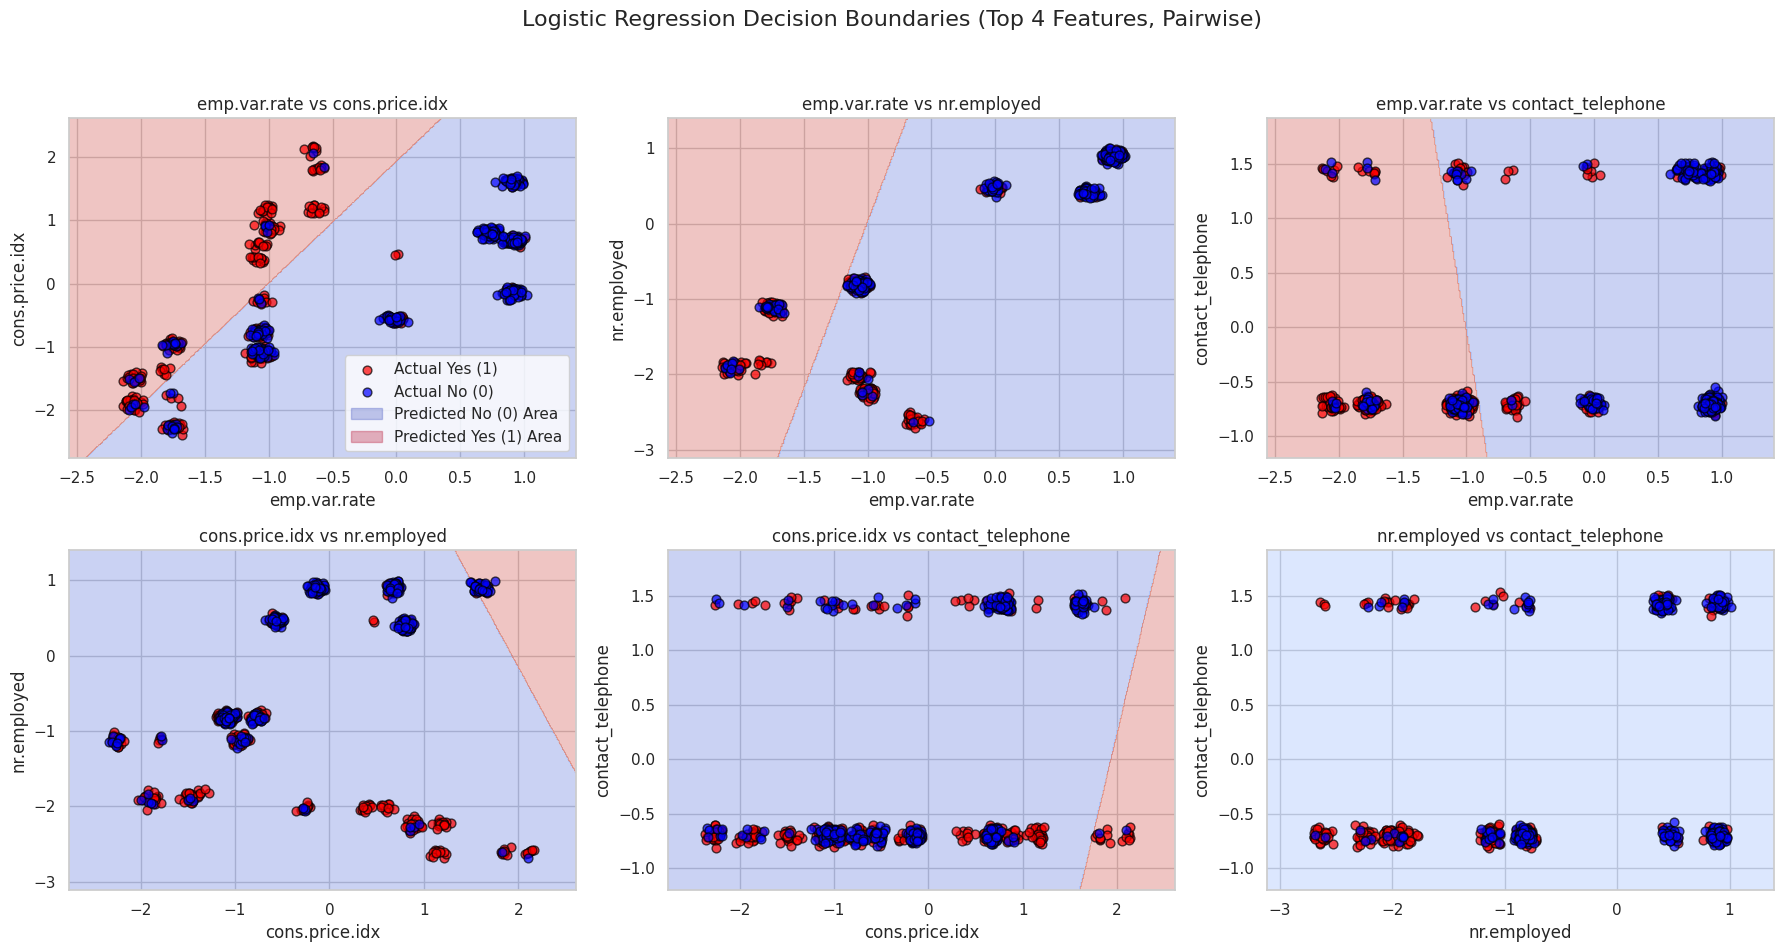

In [17]:
# 1. Get the baseline model and its coefficients
baseline_lr = models['Logistic Regression']
coefs = np.abs(baseline_lr.coef_[0])

# 2. Identify the top 4 features by absolute weight
top4_indices = np.argsort(coefs)[-4:][::-1]
top4_names = X_train.columns[top4_indices]

print("Top 4 features by absolute weight in Logistic Regression:")
for i, idx in enumerate(top4_indices):
    print(f"  {i+1}. {top4_names[i]} (weight: {baseline_lr.coef_[0][idx]:.4f})")
print("-" * 40)

# 3. Prepare background data (mean of all features for the meshgrid)
X_mean = X_train_scaled.mean(axis=0)

# Pre-sample exactly 400 of each class for all subplots to ensure consistency
np.random.seed(42)
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
sample_0 = np.random.choice(idx_0, size=400, replace=False)
sample_1 = np.random.choice(idx_1, size=400, replace=False)
sample_idx = np.concatenate([sample_0, sample_1])
y_sample = y_train.iloc[sample_idx]

# Helper function to add random jitter to scatter points
# so overlapping data points (like identical economic indices) can be seen
def add_jitter(arr, amount=0.04):
    return arr + np.random.normal(0, amount, size=arr.shape)

# 4. Create pairwise plots for the top 4 features
pairs = list(combinations(top4_indices, 2))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (f1_idx, f2_idx) in enumerate(pairs):
    ax = axes[i]

    # Determine ranges for the two features
    x_min, x_max = X_train_scaled[:, f1_idx].min() - 0.5, X_train_scaled[:, f1_idx].max() + 0.5
    y_min, y_max = X_train_scaled[:, f2_idx].min() - 0.5, X_train_scaled[:, f2_idx].max() + 0.5

    # Create meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Create grid data with all features set to mean
    grid_data = np.tile(X_mean, (xx.size, 1))
    # Override the two features we are visualizing with the meshgrid values
    grid_data[:, f1_idx] = xx.ravel()
    grid_data[:, f2_idx] = yy.ravel()

    # Predict using the already trained baseline model
    Z = baseline_lr.predict(grid_data)
    Z = Z.reshape(xx.shape)

    # Plot contour
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Plot class 1 (Yes) first
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 1], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 1], f2_idx]),
               c='red', edgecolors='black', alpha=0.7, s=40, label='Actual Yes (1)')

    # Plot class 0 (No)
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 0], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 0], f2_idx]),
               c='blue', edgecolors='black', alpha=0.7, s=40, label='Actual No (0)')

    ax.set_xlabel(X_train.columns[f1_idx])
    ax.set_ylabel(X_train.columns[f2_idx])
    ax.set_title(f"{X_train.columns[f1_idx]} vs {X_train.columns[f2_idx]}")

    if i == 0:
        # Create custom patches for the background areas
        blue_patch = mpatches.Patch(color=plt.cm.coolwarm(0.0), alpha=0.3, label='Predicted No (0) Area')
        red_patch = mpatches.Patch(color=plt.cm.coolwarm(1.0), alpha=0.3, label='Predicted Yes (1) Area')

        # Get existing handles and labels
        handles, labels = ax.get_legend_handles_labels()

        # Add custom patches to the legend
        handles.extend([blue_patch, red_patch])

        ax.legend(handles=handles, loc='best')

plt.suptitle('Logistic Regression Decision Boundaries (Top 4 Features, Pairwise)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

To draw these 2D plots, four most important features based on weights were identified. A small jitter was added to avoid complete overlap when showing data on decision boundary plots.

Because our dataset is heavily imbalanced (87% 'No'), the model has a strong baseline bias toward predicting 'No'.

In Logistic Regression, the model simply adds up the weights of all features. Here is what is happening in Subplot 6 (nr.employed vs contact_telephone):

The strongest feature by far is emp.var.rate (weight ~2.38). In Subplot 6, we locked it to its average value, which provides a strong "pull" towards the 'No' prediction.
The two features we are varying in Subplot 6 have much smaller weights (0.53 and 0.33).
Even if we push nr.employed and contact_telephone to their maximum extremes on that chart, their combined weight simply isn't strong enough to overpower the 'No' bias created by the average values of the other 44 features.
Therefore, for every single coordinate point in that specific 2D square, the model predicts 'No'. Because the prediction never flips to 'Yes' anywhere in that specific view, no boundary line is drawn.

Calculating permutation importance for KNN (this might take a moment)...

Top 4 features identified for KNN via Permutation Importance:
  1. month_oct (importance: 0.0188)
  2. month_mar (importance: 0.0090)
  3. previous (importance: 0.0060)
  4. age (importance: 0.0060)
----------------------------------------


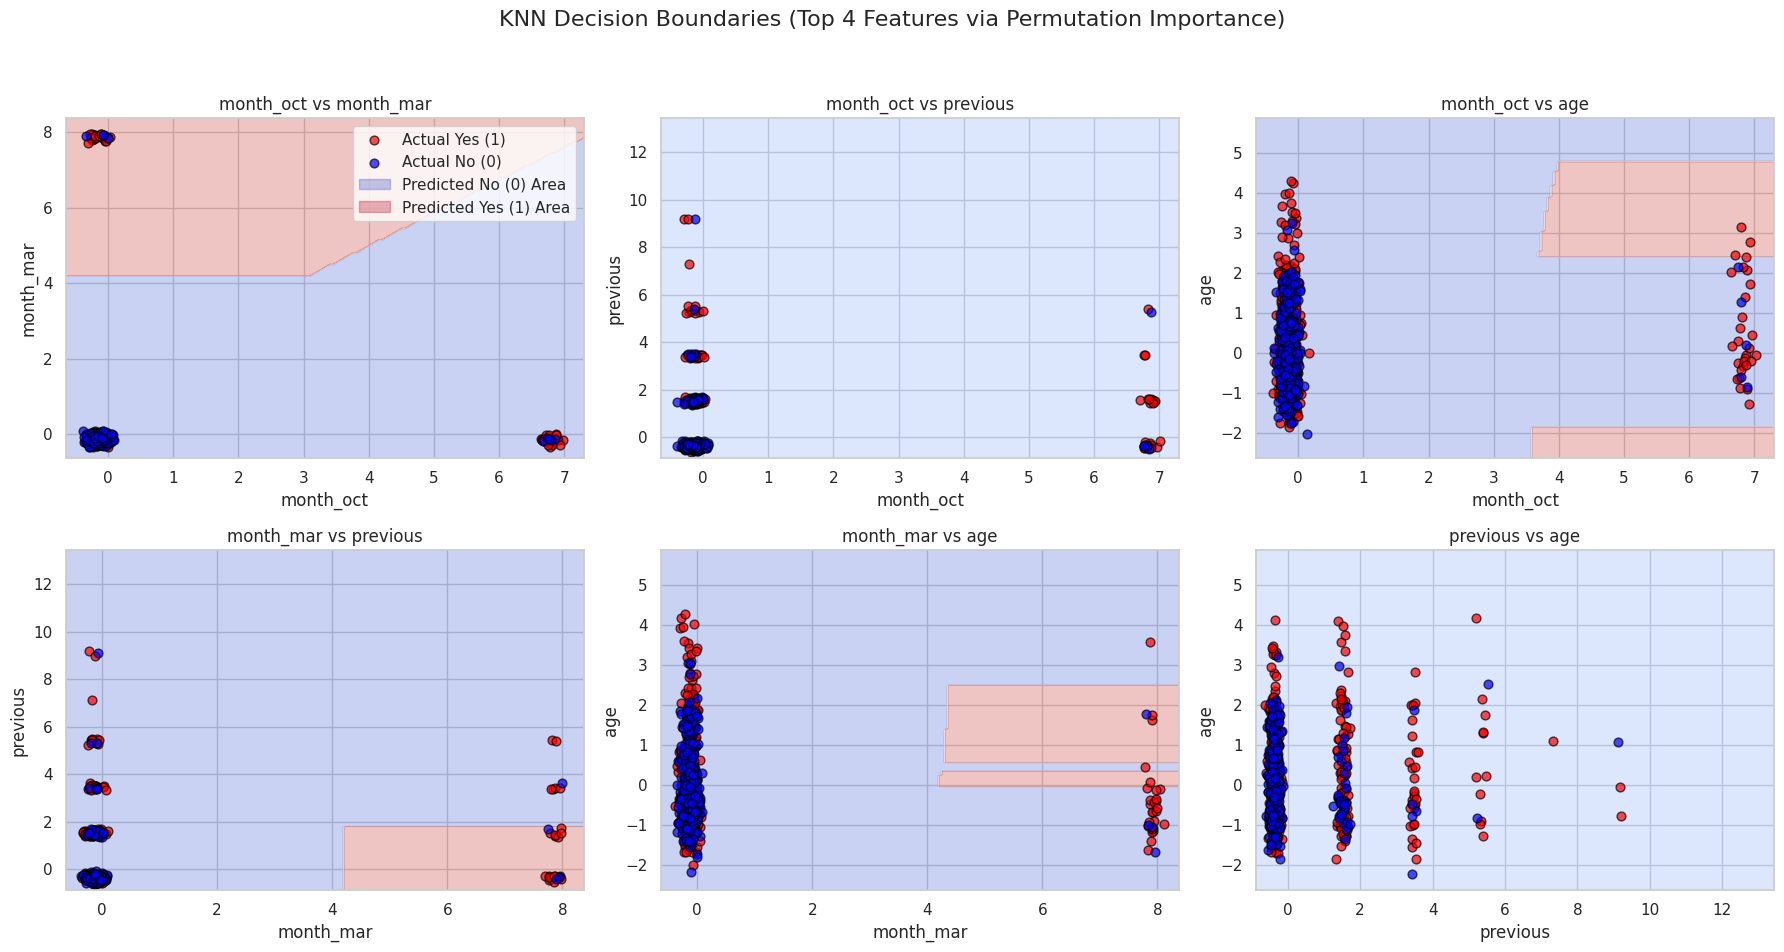

In [18]:
# 1. Get the trained baseline KNN model
baseline_knn = models['KNN']

# 2. Find feature importance for KNN using Permutation Importance
# We use a subsample of the test set to save time
print("Calculating permutation importance for KNN (this might take a moment)...")
np.random.seed(42)
sample_indices = np.random.choice(len(X_test_scaled), size=1000, replace=False)
X_test_sub = X_test_scaled[sample_indices]
y_test_sub = y_test.iloc[sample_indices]

result = permutation_importance(baseline_knn, X_test_sub, y_test_sub, n_repeats=5, random_state=42, n_jobs=-1)

# Get top 4 features
top4_indices = result.importances_mean.argsort()[-4:][::-1]
top4_names = X_train.columns[top4_indices]

print("\nTop 4 features identified for KNN via Permutation Importance:")
for i, idx in enumerate(top4_indices):
    print(f"  {i+1}. {top4_names[i]} (importance: {result.importances_mean[idx]:.4f})")
print("-" * 40)

# 3. Prepare background data (mean of all features for the meshgrid)
X_mean = X_train_scaled.mean(axis=0)

# Pre-sample exactly 200 of each class for all subplots to ensure consistency
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
sample_0 = np.random.choice(idx_0, size=400, replace=False)
sample_1 = np.random.choice(idx_1, size=400, replace=False)
sample_idx = np.concatenate([sample_0, sample_1])
y_sample = y_train.iloc[sample_idx]

# Helper function to add random jitter to scatter points
def add_jitter(arr, amount=0.08):
    return arr + np.random.normal(0, amount, size=arr.shape)

# 4. Create pairwise plots for the top 4 features (4 choose 2 = 6 combinations)
pairs = list(combinations(top4_indices, 2))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (f1_idx, f2_idx) in enumerate(pairs):
    ax = axes[i]

    # Determine ranges for the two features
    x_min, x_max = X_train_scaled[:, f1_idx].min() - 0.5, X_train_scaled[:, f1_idx].max() + 0.5
    y_min, y_max = X_train_scaled[:, f2_idx].min() - 0.5, X_train_scaled[:, f2_idx].max() + 0.5

    # Create meshgrid with a slightly coarser step size (0.05) to speed up KNN prediction
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # Create grid data with all features set to mean
    grid_data = np.tile(X_mean, (xx.size, 1))
    # Override the two features we are visualizing with the meshgrid values
    grid_data[:, f1_idx] = xx.ravel()
    grid_data[:, f2_idx] = yy.ravel()

    # Predict using the already trained KNN model
    Z = baseline_knn.predict(grid_data)
    Z = Z.reshape(xx.shape)

    # Plot contour
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Plot class 1 (Yes) first
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 1], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 1], f2_idx]),
               c='red', edgecolors='black', alpha=0.7, s=40, label='Actual Yes (1)')

    # Plot class 0 (No)
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 0], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 0], f2_idx]),
               c='blue', edgecolors='black', alpha=0.7, s=40, label='Actual No (0)')

    ax.set_xlabel(X_train.columns[f1_idx])
    ax.set_ylabel(X_train.columns[f2_idx])
    ax.set_title(f"{X_train.columns[f1_idx]} vs {X_train.columns[f2_idx]}")

    if i == 0:
        # Create custom patches for the background areas
        blue_patch = mpatches.Patch(color=plt.cm.coolwarm(0.0), alpha=0.3, label='Predicted No (0) Area')
        red_patch = mpatches.Patch(color=plt.cm.coolwarm(1.0), alpha=0.3, label='Predicted Yes (1) Area')

        # Get existing handles and labels
        handles, labels = ax.get_legend_handles_labels()

        # Add custom patches to the legend
        handles.extend([blue_patch, red_patch])

        ax.legend(handles=handles, loc='best')

plt.suptitle('KNN Decision Boundaries (Top 4 Features via Permutation Importance)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##### Questions

Dominant features identified by KNN are different from those from logistics regression.  The reason they rely on completely different features comes down to their fundamental mechanics: Global Linear Patterns vs. Local Clusters.

- Logistic Regression (Global & Linear)
Logistic regression tries to draw a single, straight mathematical line (or plane) through the entire dataset to separate the 'Yes' and 'No' classes.
Because it looks at the big picture, it heavily favors macro-level trends. This is why the economic indicators (emp.var.rate, cons.price.idx, nr.employed) are its top features. As those economic numbers go up or down, the overall probability of a 'Yes' scales linearly across the board.

- K-Nearest Neighbors (Local & Non-Linear)
KNN doesn't care about drawing a straight line. It only looks at the data points immediately surrounding a new point (its "neighbors"). It is essentially looking for local pockets or clusters of similar people.

- Features like month_oct, month_mar, and previous (number of previous contacts) might not have a clean, straight-line relationship with the target across 30,000 rows. However, people contacted in October or March who had prior contact might form very tight, specific "neighborhoods" of 'Yes' responses. KNN easily spots these dense local clusters, making those features highly important for its specific distance-based calculations.


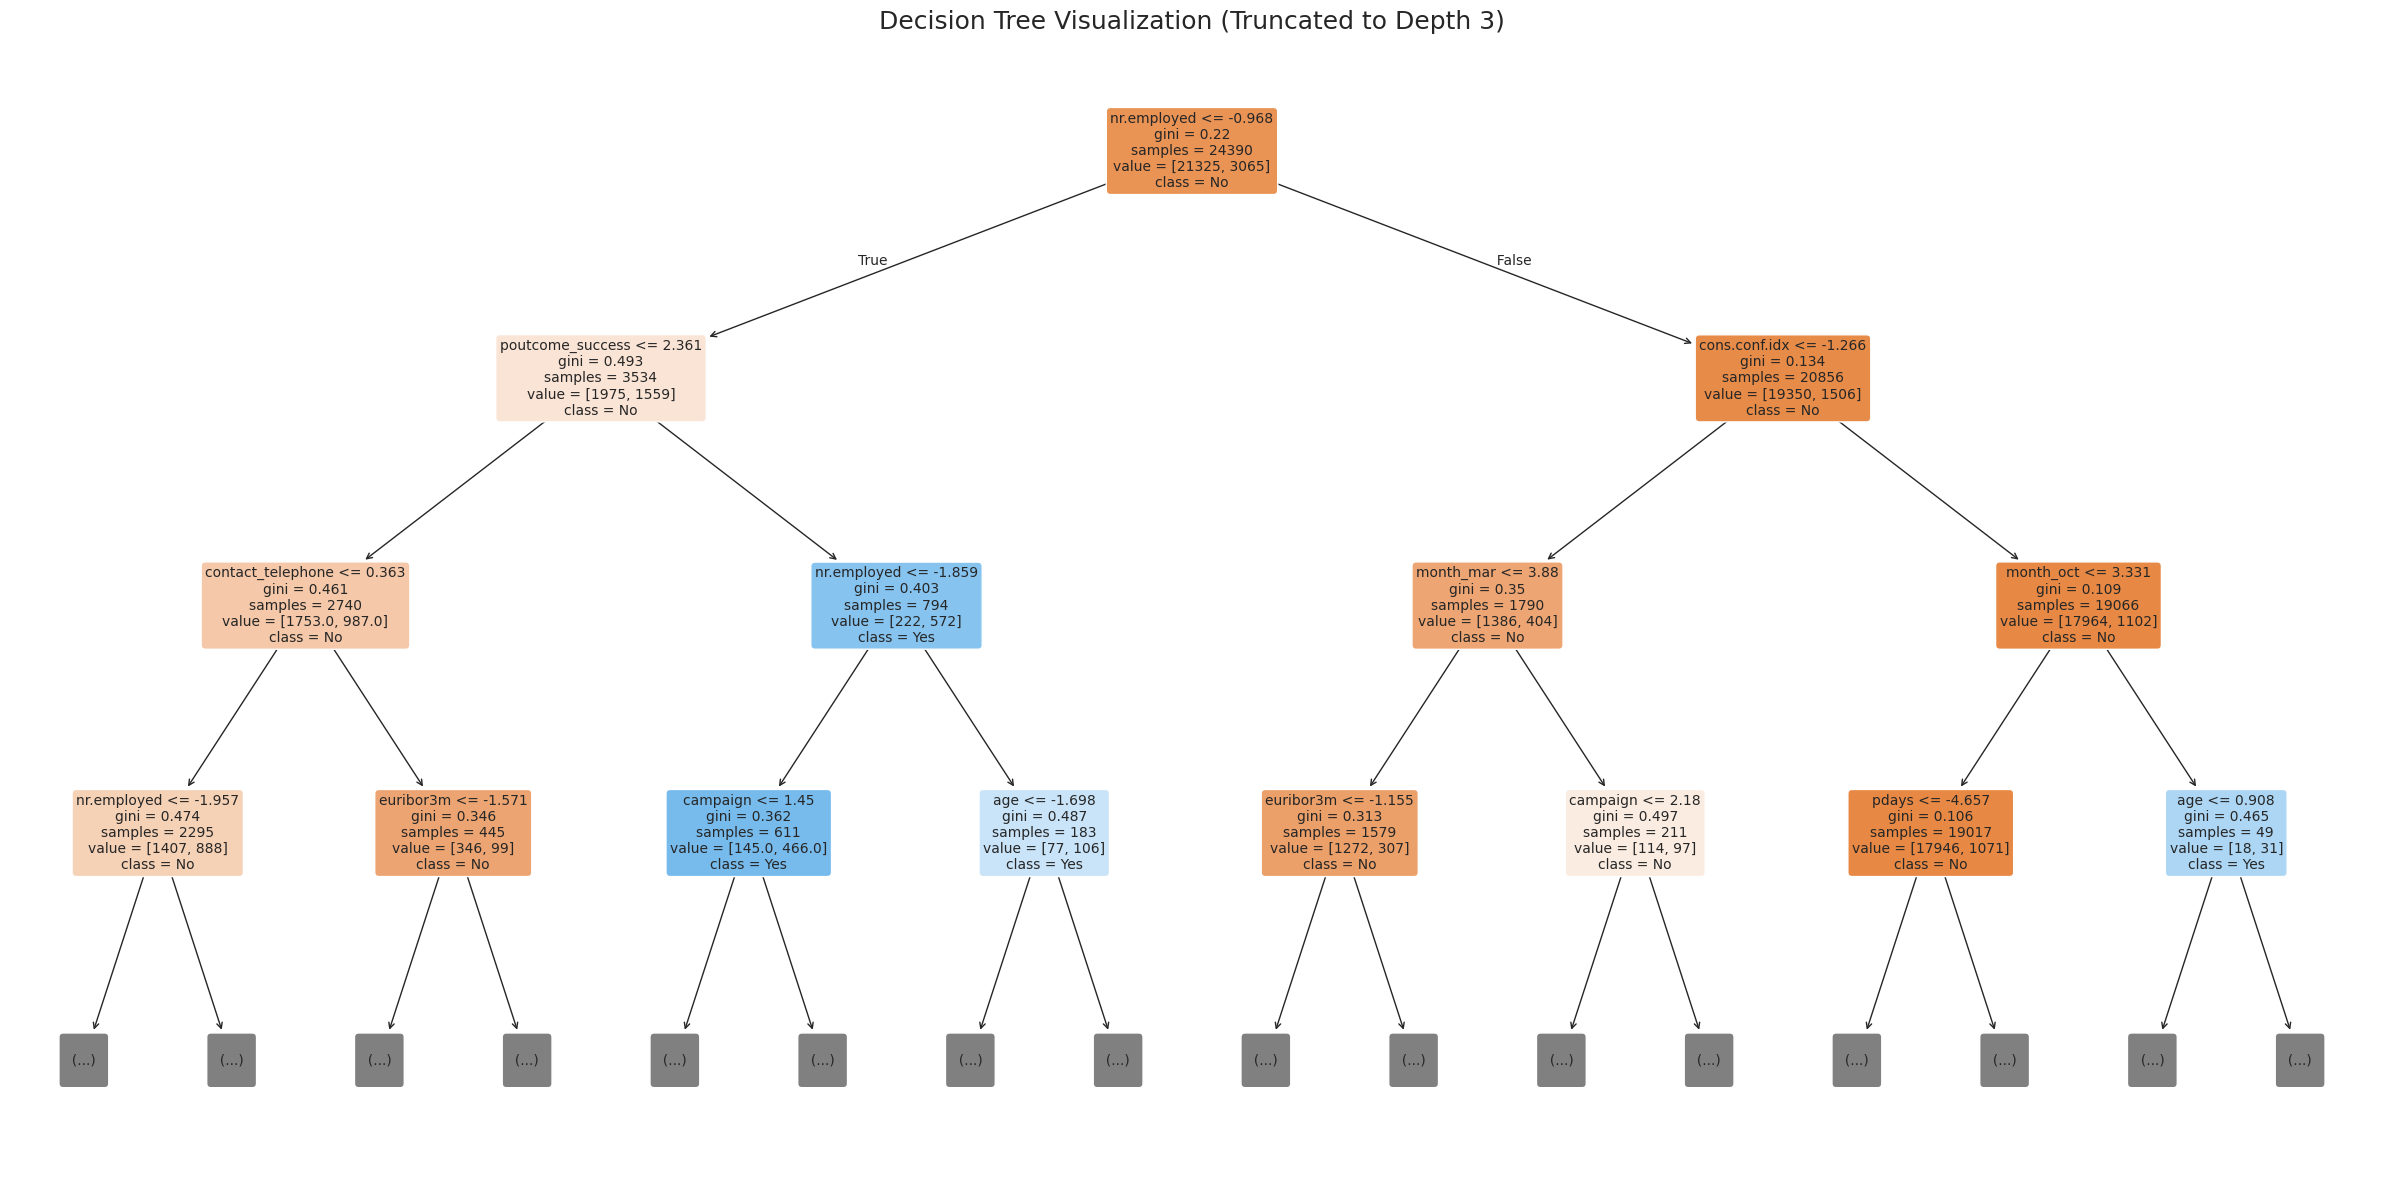

In [19]:
# 1. Get the trained baseline Decision Tree model
dt_model = models['Decision Tree']

# 2. Plot the tree
plt.figure(figsize=(24, 12))
#Limit max_depth to 3 just for visualization purposes so it's readable.
# The actual tree might be much deeper.
plot_tree(dt_model,
          feature_names=X_train.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)

plt.title('Decision Tree Visualization (Truncated to Depth 3)', fontsize=18)
plt.tight_layout()
plt.show()

Top 4 features identified for Decision Tree:
  1. nr.employed (importance: 0.1663)
  2. age (importance: 0.1653)
  3. euribor3m (importance: 0.0939)
  4. campaign (importance: 0.0843)
----------------------------------------


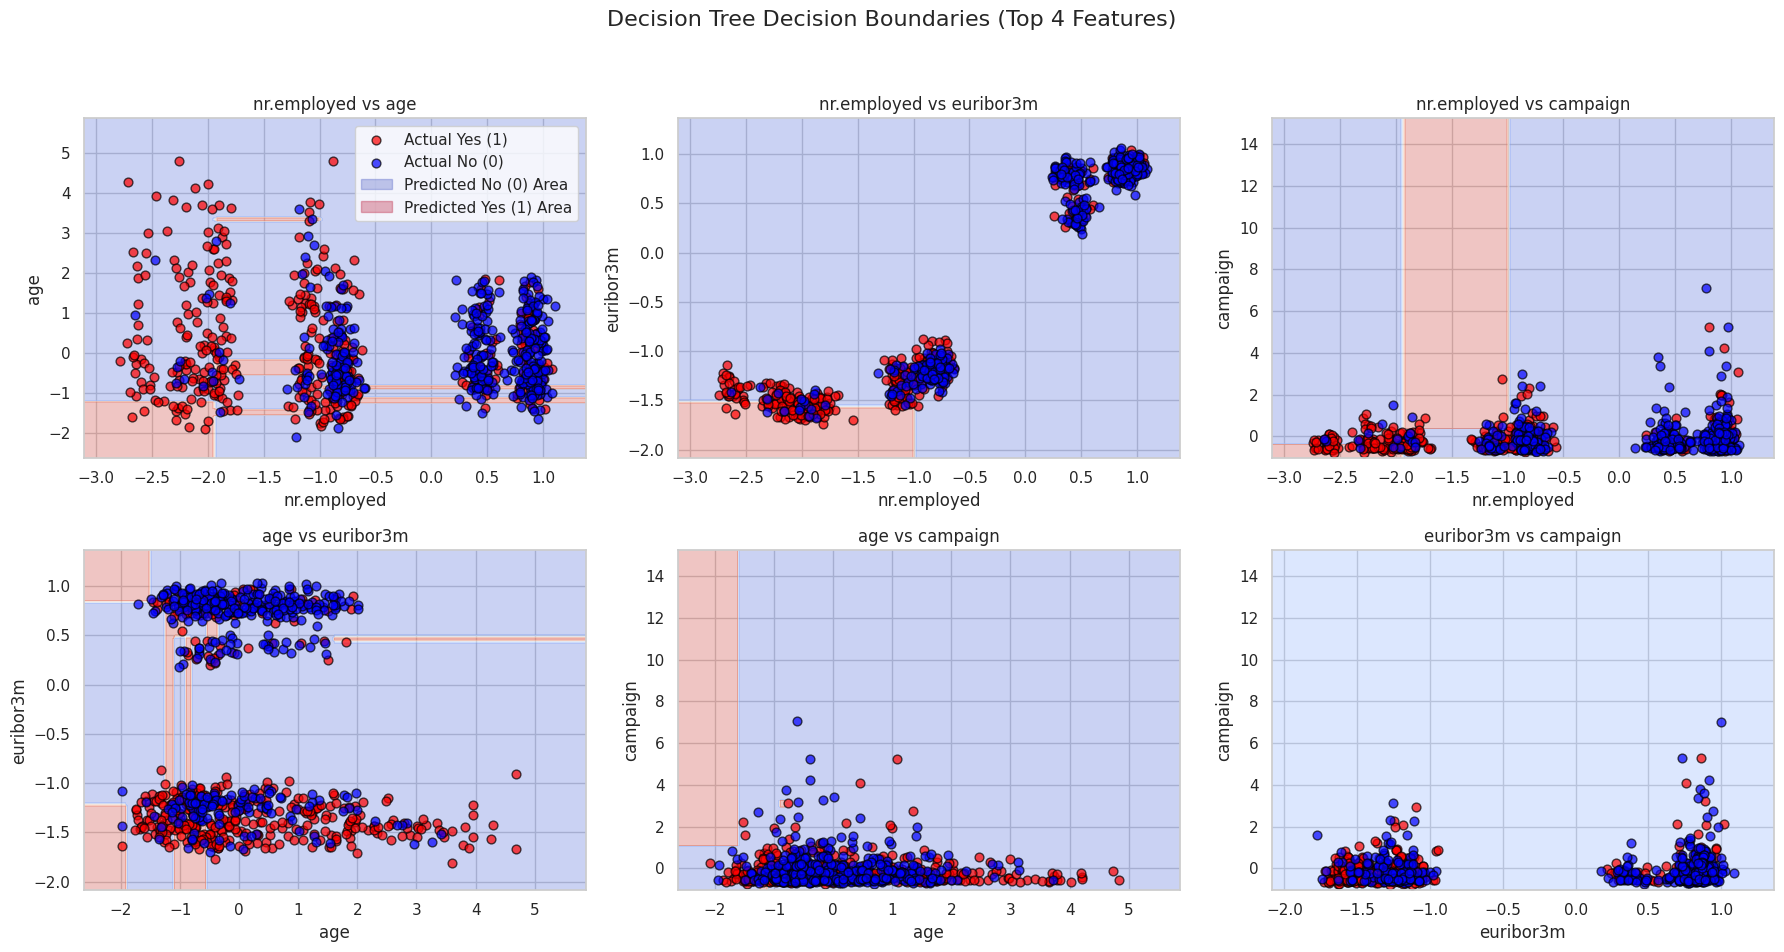

In [20]:
# 1. Get the trained baseline Decision Tree model
dt_model = models['Decision Tree']

# 2. Get top 4 features using feature_importances_
importances = dt_model.feature_importances_
top4_indices = np.argsort(importances)[-4:][::-1]
top4_names = X_train.columns[top4_indices]

print("Top 4 features identified for Decision Tree:")
for i, idx in enumerate(top4_indices):
    print(f"  {i+1}. {top4_names[i]} (importance: {importances[idx]:.4f})")
print("-" * 40)

# 3. Prepare background data (mean of all features for the meshgrid)
X_mean = X_train_scaled.mean(axis=0)

# Pre-sample exactly 400 of each class for all subplots to ensure consistency
np.random.seed(42)
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
sample_0 = np.random.choice(idx_0, size=400, replace=False)
sample_1 = np.random.choice(idx_1, size=400, replace=False)
sample_idx = np.concatenate([sample_0, sample_1])
y_sample = y_train.iloc[sample_idx]

# Helper function to add random jitter to scatter points
def add_jitter(arr, amount=0.08):
    return arr + np.random.normal(0, amount, size=arr.shape)

# 4. Create pairwise plots for the top 4 features (4 choose 2 = 6 combinations)
pairs = list(combinations(top4_indices, 2))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (f1_idx, f2_idx) in enumerate(pairs):
    ax = axes[i]

    # Determine ranges for the two features
    x_min, x_max = X_train_scaled[:, f1_idx].min() - 0.5, X_train_scaled[:, f1_idx].max() + 0.5
    y_min, y_max = X_train_scaled[:, f2_idx].min() - 0.5, X_train_scaled[:, f2_idx].max() + 0.5

    # Create meshgrid with a slightly coarser step size (0.05)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # Create grid data with all features set to mean
    grid_data = np.tile(X_mean, (xx.size, 1))
    # Override the two features we are visualizing with the meshgrid values
    grid_data[:, f1_idx] = xx.ravel()
    grid_data[:, f2_idx] = yy.ravel()

    # Predict using the already trained Decision Tree model
    Z = dt_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    # Plot contour
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Plot class 1 (Yes) first
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 1], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 1], f2_idx]),
               c='red', edgecolors='black', alpha=0.7, s=40, label='Actual Yes (1)')

    # Plot class 0 (No)
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 0], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 0], f2_idx]),
               c='blue', edgecolors='black', alpha=0.7, s=40, label='Actual No (0)')

    ax.set_xlabel(X_train.columns[f1_idx])
    ax.set_ylabel(X_train.columns[f2_idx])
    ax.set_title(f"{X_train.columns[f1_idx]} vs {X_train.columns[f2_idx]}")

    if i == 0:
        # Create custom patches for the background areas
        blue_patch = mpatches.Patch(color=plt.cm.coolwarm(0.0), alpha=0.3, label='Predicted No (0) Area')
        red_patch = mpatches.Patch(color=plt.cm.coolwarm(1.0), alpha=0.3, label='Predicted Yes (1) Area')

        # Get existing handles and labels
        handles, labels = ax.get_legend_handles_labels()

        # Add custom patches to the legend
        handles.extend([blue_patch, red_patch])

        ax.legend(handles=handles, loc='best')

plt.suptitle('Decision Tree Decision Boundaries (Top 4 Features)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

As you can see from the output, the top 4 features identified by the Decision Tree are nr.employed, age, euribor3m, and campaign.

Unlike the smooth linear plane of Logistic Regression or the bubbly islands of KNN, the Decision Tree creates very rigid, blocky, and rectangular boundaries. This happens because a Decision Tree makes decisions by splitting the data using strict horizontal and vertical cutoffs (e.g., "if age > 40"), leading to these grid-like regions.

In [ ]:
# 1. Get the trained baseline SVM model
svm_model = models['SVM']

# 2. Find feature importance for SVM using Permutation Importance
# We use a subsample of the test set to save time
print("Calculating permutation importance for SVM (this might take a moment)...")
np.random.seed(42)
sample_indices = np.random.choice(len(X_test_scaled), size=1000, replace=False)
X_test_sub = X_test_scaled[sample_indices]
y_test_sub = y_test.iloc[sample_indices]

result = permutation_importance(svm_model, X_test_sub, y_test_sub, n_repeats=5, random_state=42, n_jobs=-1)

# Get top 4 features
top4_indices = result.importances_mean.argsort()[-4:][::-1]
top4_names = X_train.columns[top4_indices]

print("\nTop 4 features identified for SVM via Permutation Importance:")
for i, idx in enumerate(top4_indices):
    print(f"  {i+1}. {top4_names[i]} (importance: {result.importances_mean[idx]:.4f})")
print("-" * 40)

# 3. Prepare background data (mean of all features for the meshgrid)
X_mean = X_train_scaled.mean(axis=0)

# Pre-sample exactly 400 of each class for all subplots to ensure consistency
np.random.seed(42)
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
sample_0 = np.random.choice(idx_0, size=400, replace=False)
sample_1 = np.random.choice(idx_1, size=400, replace=False)
sample_idx = np.concatenate([sample_0, sample_1])
y_sample = y_train.iloc[sample_idx]

# Helper function to add random jitter to scatter points
def add_jitter(arr, amount=0.08):
    return arr + np.random.normal(0, amount, size=arr.shape)

# 4. Create pairwise plots for the top 4 features (4 choose 2 = 6 combinations)
pairs = list(combinations(top4_indices, 2))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (f1_idx, f2_idx) in enumerate(pairs):
    ax = axes[i]

    # Determine ranges for the two features
    x_min, x_max = X_train_scaled[:, f1_idx].min() - 0.5, X_train_scaled[:, f1_idx].max() + 0.5
    y_min, y_max = X_train_scaled[:, f2_idx].min() - 0.5, X_train_scaled[:, f2_idx].max() + 0.5

    # Create meshgrid with a slightly coarser step size (0.05) to speed up SVM prediction
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # Create grid data with all features set to mean
    grid_data = np.tile(X_mean, (xx.size, 1))
    # Override the two features we are visualizing with the meshgrid values
    grid_data[:, f1_idx] = xx.ravel()
    grid_data[:, f2_idx] = yy.ravel()

    # Predict using the already trained SVM model
    Z = svm_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    # Plot contour
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Plot class 1 (Yes) first
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 1], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 1], f2_idx]),
               c='red', edgecolors='black', alpha=0.7, s=40, label='Actual Yes (1)')

    # Plot class 0 (No)
    ax.scatter(add_jitter(X_train_scaled[sample_idx[y_sample == 0], f1_idx]),
               add_jitter(X_train_scaled[sample_idx[y_sample == 0], f2_idx]),
               c='blue', edgecolors='black', alpha=0.7, s=40, label='Actual No (0)')

    ax.set_xlabel(X_train.columns[f1_idx])
    ax.set_ylabel(X_train.columns[f2_idx])
    ax.set_title(f"{X_train.columns[f1_idx]} vs {X_train.columns[f2_idx]}")

    if i == 0:
        # Create custom patches for the background areas
        blue_patch = mpatches.Patch(color=plt.cm.coolwarm(0.0), alpha=0.3, label='Predicted No (0) Area')
        red_patch = mpatches.Patch(color=plt.cm.coolwarm(1.0), alpha=0.3, label='Predicted Yes (1) Area')

        # Get existing handles and labels
        handles, labels = ax.get_legend_handles_labels()

        # Add custom patches to the legend
        handles.extend([blue_patch, red_patch])

        ax.legend(handles=handles, loc='best')

plt.suptitle('SVM Decision Boundaries (Top 4 Features via Permutation Importance)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Calculating permutation importance for SVM (this might take a moment)...


Because the baseline SVM uses an RBF (Radial Basis Function) kernel, it models non-linear relationships and does not calculate straightforward feature weights like Logistic Regression. Therefore, Permutation Importance was used again to find the SVM's top 4 most important features, and then plot the 2D pairwise boundaries.
SVM boundaries to look like smooth, curving lines, or even fully enclosed "bubbles" surrounding clusters of data points.